# Anomaly Detection: Identifying Nutritionally Unusual Food Products

### AAI-590 Capstone Project - University of San Diego
### Team Members:
 - Jamshed Nabizada
 - Swapnil Patil

## Purpose

This notebook implements the **second use case** of the NutriVision AI system: identifying nutritionally anomalous food products by measuring how much they deviate from a **whole-food baseline** (NOVA 1 — Unprocessed Foods).

All three anomaly models are trained **exclusively on NOVA 1 samples** from the training set. Products with high anomaly scores deviate significantly from what a whole food looks like nutritionally, independent of their NOVA classification tier.

**This complements Use Case 1 (NOVA tier classification) by adding:**
- A continuous *distance-from-whole-food* signal that augments the discrete NOVA tier
- Detection of nutritionally extreme outliers even within a tier (e.g., an unusually additive-laden NOVA 2 product)
- A data-quality flag for products with implausible nutritional profiles

**Three complementary anomaly detection models are trained and compared:**
1. **Autoencoder** — MLPRegressor auto-associative bottleneck network; high reconstruction error = anomaly
2. **Isolation Forest** — Random partition ensemble; short isolation path = anomaly
3. **One-Class SVM** — RBF kernel boundary around NOVA 1; outside boundary = anomaly

**Workflow:**
1. Load prepared data splits and artifacts from Notebooks 02 and 04
2. Establish the NOVA 1 whole-food baseline statistical profile
3. Train each anomaly detector on scaled NOVA 1 training samples
4. Score all test samples (NOVA 1–4) with each model and select thresholds
5. Compare anomaly rates across NOVA groups for all three models
6. Ensemble results via majority vote and analyze flagged products
7. Demonstrate a combined NOVA classification + anomaly scoring inference pipeline
8. Save trained models and computed scores as artifacts

## Environment Setup and Configuration

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# force-reload src modules so code changes are always picked up
%load_ext autoreload
%autoreload 2

import json
import time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from IPython.display import display

from src.modeling import (
    ARTIFACTS_DIR,
    NOVA_LABELS,
    RANDOM_STATE,
    RESULTS_DIR,
)
from src.anomaly import (
    NOVA_COLORS,
    MODEL_COLORS,
    AnomalyTrainer,
    AnomalyScorer,
    AnomalyPlotter,
    predict_nova_and_anomaly,
)

np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

# shared instances used throughout the notebook
trainer = AnomalyTrainer(random_state=RANDOM_STATE)
scorer  = AnomalyScorer(ae_percentile=95)
plotter = AnomalyPlotter()

print("Environment ready.")

Environment ready.


## Load Data and Artifacts

Load the train/validation/test splits produced by the Feature Engineering notebook (Notebook 02), and the fitted StandardScaler. The **scaled** feature matrices are used for all anomaly models, because distance-based and kernel methods are sensitive to feature scale.

In [3]:
# load saved splits and metadata from Feature Engineering notebook (Notebook 02)
splits = joblib.load(ARTIFACTS_DIR / "data_splits.joblib")

# unscaled splits (used for feature inspection and the final inference function)
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

# scaled versions — used for all three anomaly detection models
X_train_scaled = splits["X_train_scaled"]
X_val_scaled   = splits["X_val_scaled"]
X_test_scaled  = splits["X_test_scaled"]

# feature names and the fitted scaler
feature_names = splits["feature_names"]
scaler        = joblib.load(ARTIFACTS_DIR / "standard_scaler.joblib")

# combine train + val scaled data to give anomaly models more NOVA 1 examples
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval        = pd.concat([y_train, y_val], ignore_index=True)

# verify y values: nova labels are 0-indexed (0=NOVA1, 1=NOVA2, 2=NOVA3, 3=NOVA4)
print(f"y unique values: {sorted(y_test.unique())}  →  NOVA groups 1-4 (0-indexed)")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Train: {X_train.shape}   Val: {X_val.shape}   Test: {X_test.shape}")

y unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  →  NOVA groups 1-4 (0-indexed)
Features (20): ['energy_100g', 'fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'saturated_fat_100g', 'additives_n', 'trans_fat_100g', 'added_sugars_100g', 'monounsaturated_fat_100g', 'polyunsaturated_fat_100g', 'starch_100g', 'nutriscore_score', 'sugar_fiber_ratio', 'fat_protein_ratio', 'additives_per_energy', 'trans_fat_ratio', 'unsaturated_fat_ratio']
Train: (134343, 20)   Val: (44781, 20)   Test: (44782, 20)


In [4]:
# ── Extract NOVA 1 (whole-food) training data ─────────────────────────────────
# All three anomaly models train ONLY on NOVA 1 samples.
# y == 0 corresponds to NOVA 1 (unprocessed foods) in the 0-indexed encoding.

nova1_mask_trainval = (y_trainval == 0)
nova1_mask_test     = (y_test == 0)

X_nova1_train = X_trainval_scaled[nova1_mask_trainval.values]  # training baseline
X_nova1_test  = X_test_scaled[nova1_mask_test.values]          # NOVA 1 test portion

print(f"NOVA 1 training samples (train + val combined): {X_nova1_train.shape[0]:,}")
print(f"NOVA 1 test samples:                            {X_nova1_test.shape[0]:,}")
print()

# split test set by NOVA group for per-group evaluation
for g in range(4):
    mask  = (y_test.values == g)
    count = mask.sum()
    pct   = count / len(y_test) * 100
    print(f"  NOVA {g+1} test: {count:,} samples ({pct:.1f}%)")

NOVA 1 training samples (train + val combined): 21,505
NOVA 1 test samples:                            5,377

  NOVA 1 test: 5,377 samples (12.0%)
  NOVA 2 test: 1,643 samples (3.7%)
  NOVA 3 test: 8,992 samples (20.1%)
  NOVA 4 test: 28,770 samples (64.2%)


---
## NOVA 1 Whole-Food Baseline Profile

Before training the anomaly models, we characterise the NOVA 1 distribution: this is the "normal" the detectors learn. Products that deviate sharply from these statistics will receive high anomaly scores.

In [5]:
# statistical summary of NOVA 1 scaled nutritional features
nova1_df = pd.DataFrame(X_nova1_train, columns=feature_names)
print("NOVA 1 (Whole Foods) — Scaled Feature Summary")
display(nova1_df.describe().round(3))

NOVA 1 (Whole Foods) — Scaled Feature Summary


,energy_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,saturated_fat_100g,additives_n,trans_fat_100g,added_sugars_100g,monounsaturated_fat_100g,polyunsaturated_fat_100g,starch_100g,nutriscore_score,sugar_fiber_ratio,fat_protein_ratio,additives_per_energy,trans_fat_ratio,unsaturated_fat_ratio
count,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.000,21505.0,21505.000
mean,-0.372,-0.353,-0.168,-0.382,0.413,0.033,-0.457,-0.444,-0.735,-0.036,-0.495,-0.051,-0.006,0.187,-0.930,-0.129,-0.138,-0.111,0.0,0.188
std,0.961,0.780,1.020,0.557,1.603,1.055,0.505,0.546,0.113,0.638,0.239,0.467,0.990,1.471,0.714,0.446,0.101,0.879,0.0,1.211
min,-1.430,-0.726,-1.058,-0.701,-0.709,-0.995,-0.570,-0.700,-0.764,-0.055,-0.509,-0.353,-0.757,-0.328,-2.954,-0.217,-0.140,-0.204,0.0,-0.333
25%,-1.176,-0.711,-0.908,-0.650,-0.570,-0.866,-0.566,-0.697,-0.764,-0.055,-0.509,-0.078,-0.063,-0.328,-1.390,-0.217,-0.140,-0.204,0.0,-0.333
50%,-0.806,-0.640,-0.664,-0.500,-0.263,-0.287,-0.550,-0.653,-0.764,-0.055,-0.509,-0.078,-0.063,-0.321,-1.055,-0.217,-0.140,-0.204,0.0,-0.333
75%,0.474,-0.382,0.681,-0.380,0.519,0.639,-0.492,-0.416,-0.764,-0.055,-0.509,-0.078,-0.063,-0.313,-0.273,-0.217,-0.140,-0.204,0.0,-0.333
max,2.941,4.516,2.397,3.835,6.443,5.439,7.192,3.759,0.832,27.862,4.152,14.458,30.346,5.672,2.854,7.352,7.557,9.213,0.0,3.006


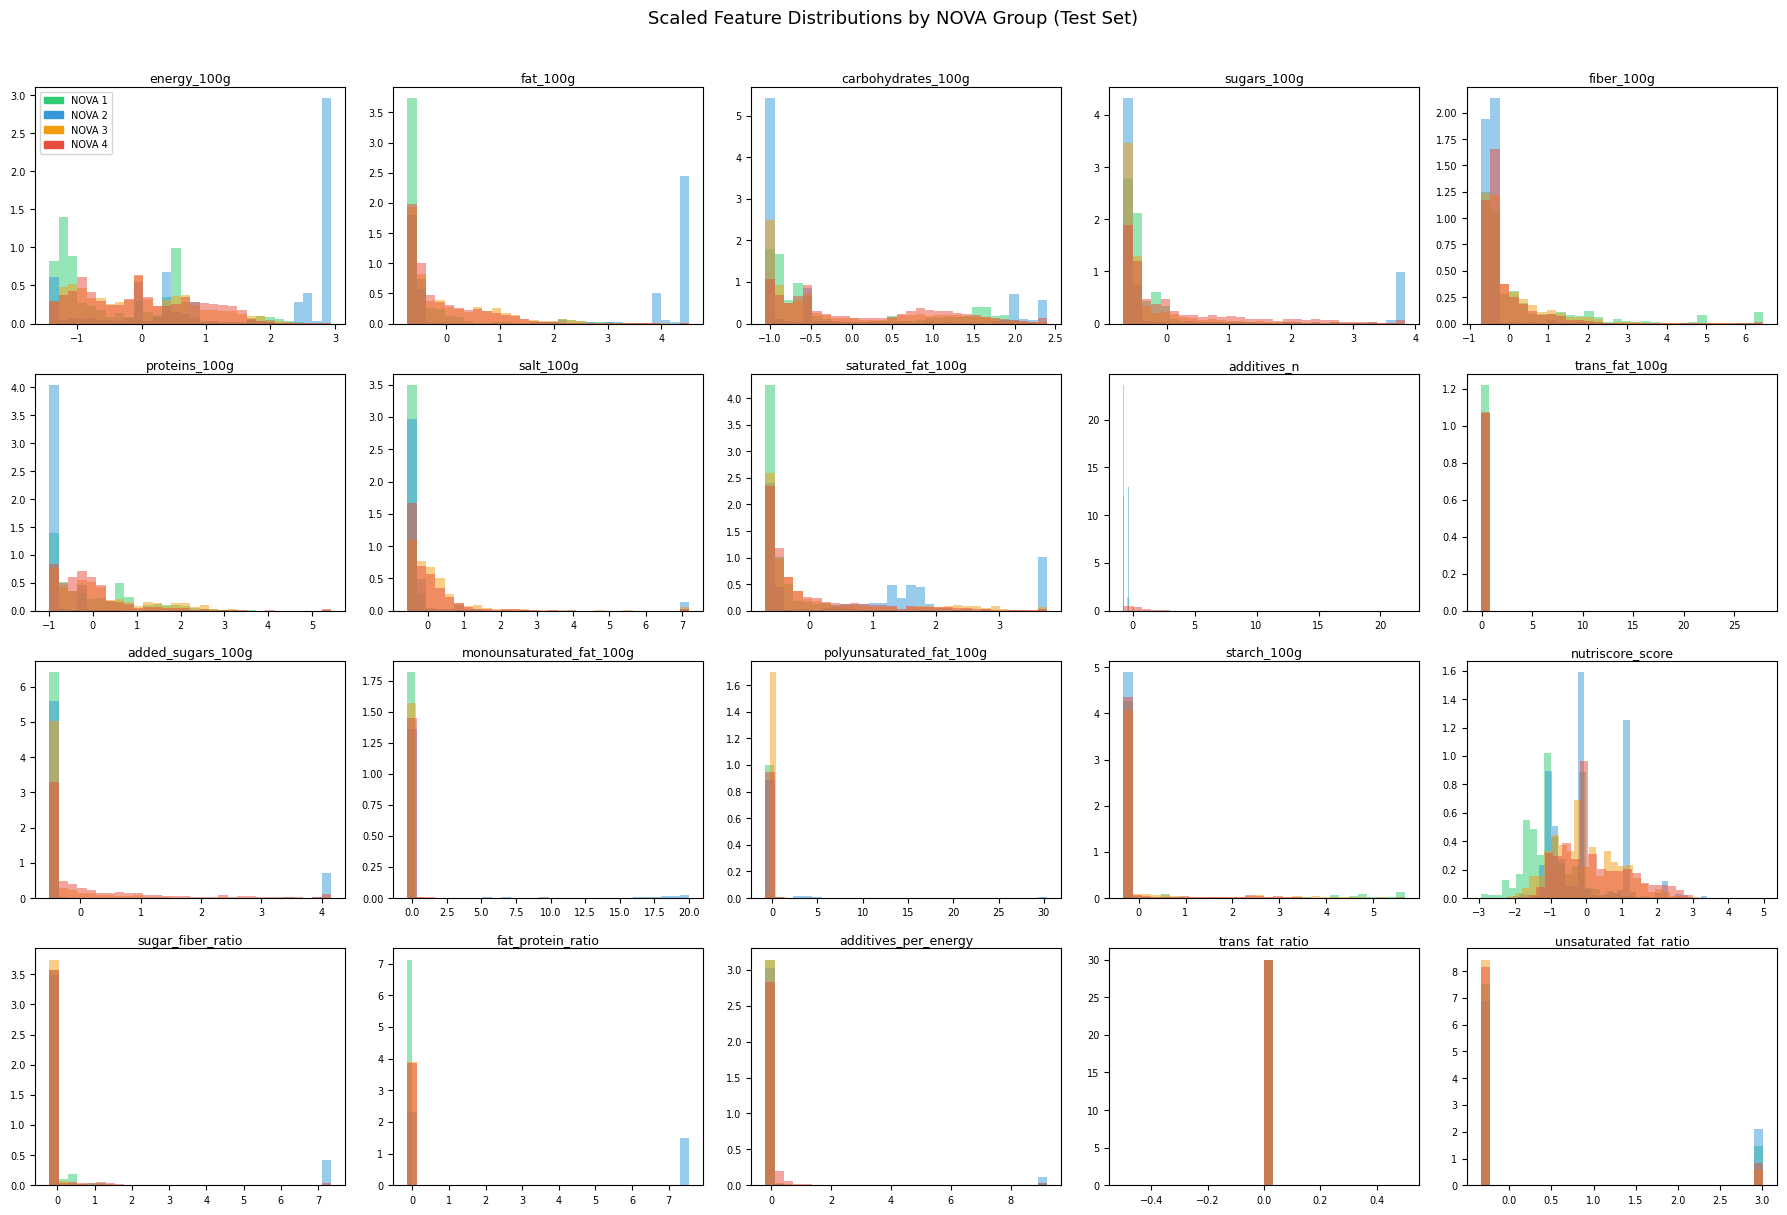

In [6]:
plotter.plot_feature_distributions(X_test_scaled, y_test.values, feature_names)

---
## Model 1: Autoencoder (MLPRegressor Auto-Associative Network)

An **autoencoder** is a neural network trained to reconstruct its own input through a compressed bottleneck representation. When trained on NOVA 1 data only, the network learns a compact encoding of what whole foods look like nutritionally.

**Architecture:** `Input (n_features) → 64 → 32 → 8 (bottleneck) → 32 → 64 → Output (n_features)`

**Anomaly score:** Mean squared error between the original feature vector and its reconstruction. The model reconstructs NOVA 1 patterns accurately but struggles with out-of-distribution NOVA 4 products — resulting in higher reconstruction error for anomalous samples.

**Threshold:** 95th percentile of NOVA 1 *training* reconstruction errors (i.e., products more extreme than 95% of whole foods are flagged).

In [7]:
autoencoder = trainer.train_autoencoder(X_nova1_train)

Training Autoencoder on NOVA 1 samples …
Done in 16.5s  |  iterations: 126  |  best val loss: 0.826552


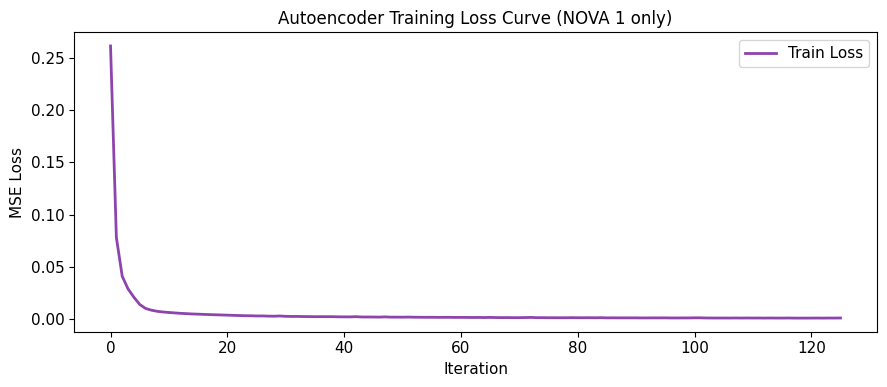

In [8]:
plotter.plot_loss_curve(autoencoder)

In [9]:
# fit threshold on NOVA 1 training errors, then score the full test set
ae_threshold               = scorer.fit_ae_threshold(autoencoder, X_nova1_train)
ae_scores_test, ae_anomalies = scorer.score_autoencoder(autoencoder, X_test_scaled)

Autoencoder anomaly threshold (95th pct of NOVA 1 train errors): 0.009474
Autoencoder — anomalies flagged: 29,517 / 44,782  (65.9%)


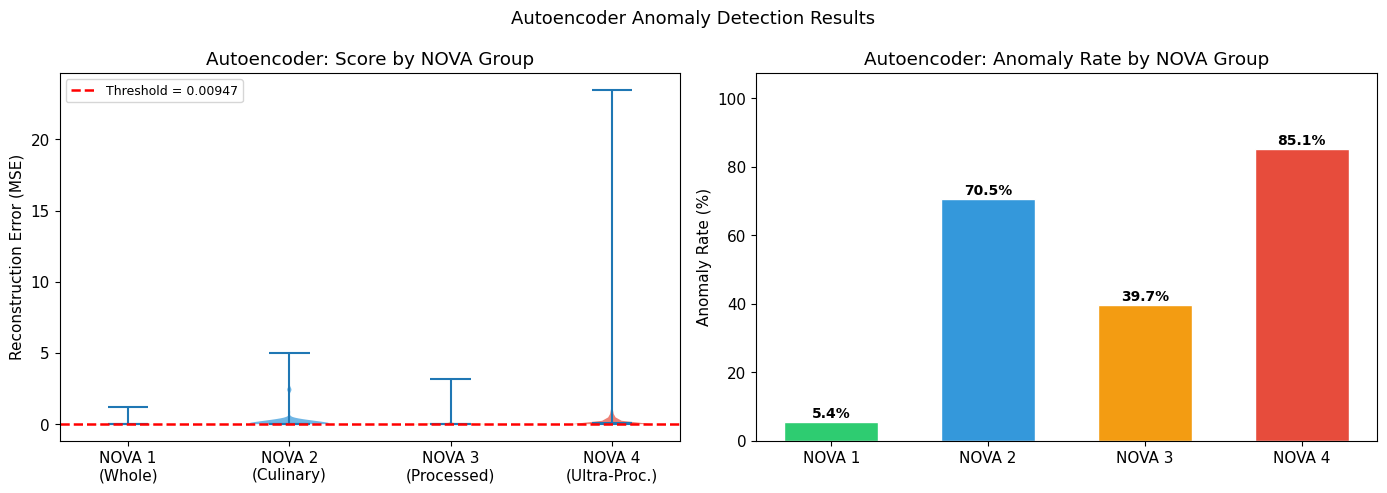

In [10]:
plotter.plot_score_violin_and_rate(
    scores          = ae_scores_test,
    anomalies       = ae_anomalies,
    y_test_0indexed = y_test.values,
    title_prefix    = "Autoencoder",
    score_ylabel    = "Reconstruction Error (MSE)",
    threshold       = ae_threshold,
)

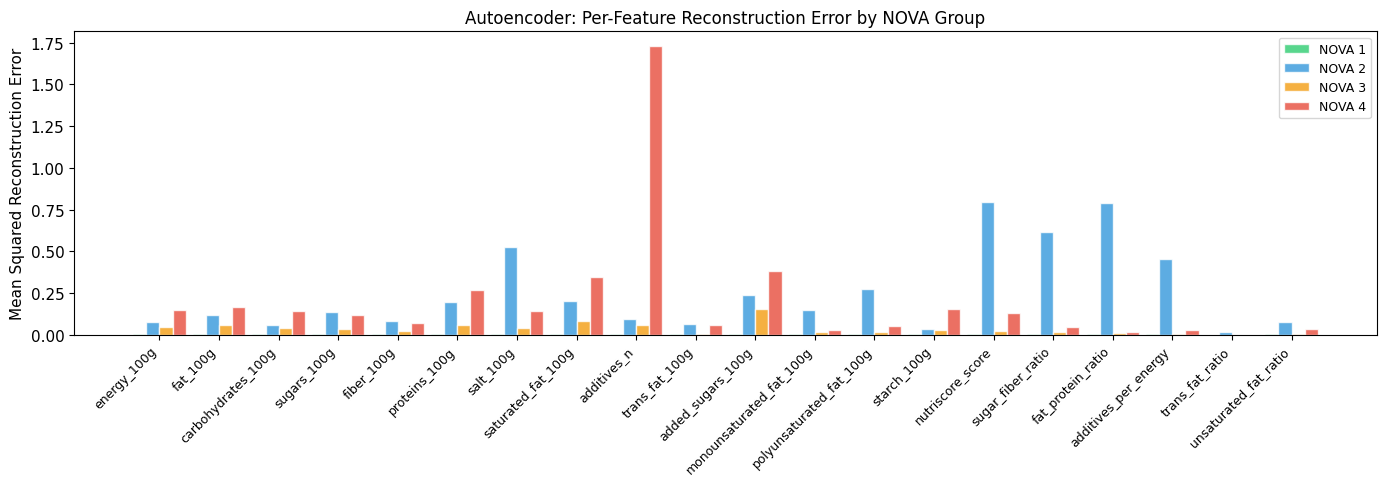

Top 5 features with highest reconstruction error for NOVA 4:
additives_n           1.731486
added_sugars_100g     0.383563
saturated_fat_100g    0.344553
proteins_100g         0.269265
fat_100g              0.168536


In [11]:
plotter.plot_per_feature_reconstruction_error(
    autoencoder     = autoencoder,
    X_test_scaled   = X_test_scaled,
    y_test_0indexed = y_test.values,
    feature_names   = feature_names,
)

---
## Model 2: Isolation Forest

**Isolation Forest** detects anomalies by recursively partitioning the feature space with random splits. Anomalous points are isolated in **fewer splits** (shorter average path length) because they are sparse and different from the bulk of the training distribution.

**Key advantages:**
- No distance metric required — works well in higher-dimensional spaces
- Efficient: `O(n log n)` training and scoring
- `contamination=0.05` sets the expected fraction of outliers in the NOVA 1 training set

**Anomaly score:** Negated `decision_function` output (higher = more anomalous). The natural threshold is 0: samples with `decision_function < 0` are flagged as anomalies.

In [12]:
iso_forest = trainer.train_isolation_forest(X_nova1_train)

Training Isolation Forest on NOVA 1 samples …
Done in 0.9s  |  n_estimators: 300  |  max_samples per tree: 256


In [13]:
if_scores_test, if_anomalies = scorer.score_isolation_forest(iso_forest, X_test_scaled)

Isolation Forest — anomalies flagged: 23,014 / 44,782  (51.4%)


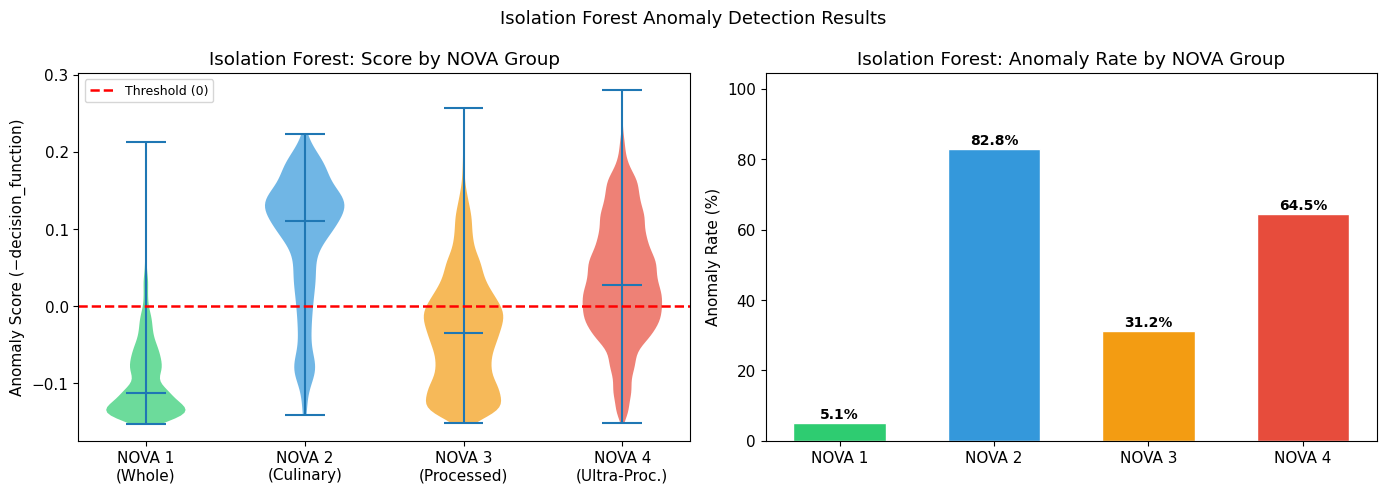

In [14]:
plotter.plot_score_violin_and_rate(
    scores          = if_scores_test,
    anomalies       = if_anomalies,
    y_test_0indexed = y_test.values,
    title_prefix    = "Isolation Forest",
    score_ylabel    = "Anomaly Score (−decision_function)",
)

---
## Model 3: One-Class SVM (OCSVM)

**One-Class SVM** maps training data into a high-dimensional feature space via an RBF kernel and finds the maximum-margin hyperplane separating the origin from the data. New samples falling outside this boundary are flagged as anomalies.

**Key hyperparameters:**
- `kernel="rbf"` — captures non-linear nutritional feature relationships
- `nu=0.05` — upper bound on the fraction of training outliers and lower bound on the fraction of support vectors; tightly controls the boundary hardness
- `gamma="scale"` — `1 / (n_features × Var(X))` — scales automatically with feature dimensionality

**Anomaly score:** Negated `decision_function` (consistent sign convention with the other two models).

In [15]:
oc_svm = trainer.train_one_class_svm(X_nova1_train)

Training One-Class SVM on NOVA 1 samples …
Done in 2.2s  |  kernel: rbf  |  nu: 0.05  |  gamma: scale  |  support vectors: 1,093


In [16]:
svm_scores_test, svm_anomalies = scorer.score_one_class_svm(oc_svm, X_test_scaled)

One-Class SVM — anomalies flagged: 14,866 / 44,782  (33.2%)


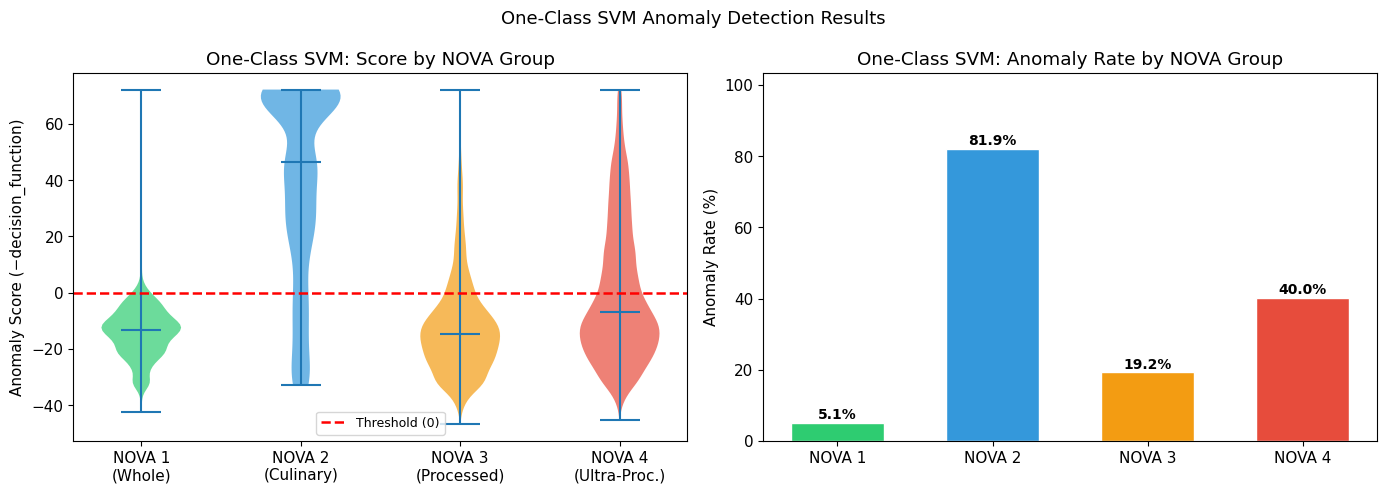

In [17]:
plotter.plot_score_violin_and_rate(
    scores          = svm_scores_test,
    anomalies       = svm_anomalies,
    y_test_0indexed = y_test.values,
    title_prefix    = "One-Class SVM",
    score_ylabel    = "Anomaly Score (−decision_function)",
)

---
## Ensemble: Majority Vote and Score Fusion

Combining all three models reduces the individual false-positive rate and produces a more robust anomaly signal:

- **Binary ensemble (majority vote):** a sample is flagged if **≥ 2 out of 3** models independently flag it as an anomaly
- **Continuous ensemble score:** each model's raw score is MinMax-normalised to [0, 1] over the test batch, then averaged — giving a calibrated 0→1 "distance from whole-food baseline"

In [18]:
flags_df = scorer.build_ensemble(
    ae_anomalies    = ae_anomalies,
    if_anomalies    = if_anomalies,
    svm_anomalies   = svm_anomalies,
    ae_scores       = ae_scores_test,
    if_scores       = if_scores_test,
    svm_scores      = svm_scores_test,
    y_test_0indexed = y_test.values,
)


Ensemble anomaly rates by NOVA group (majority vote ≥ 2/3):
  NOVA 1:   4.1%  (218 / 5,377)
  NOVA 2:  82.5%  (1,355 / 1,643)
  NOVA 3:  27.9%  (2,512 / 8,992)
  NOVA 4:  66.2%  (19,040 / 28,770)

Overall ensemble anomaly rate: 51.6%


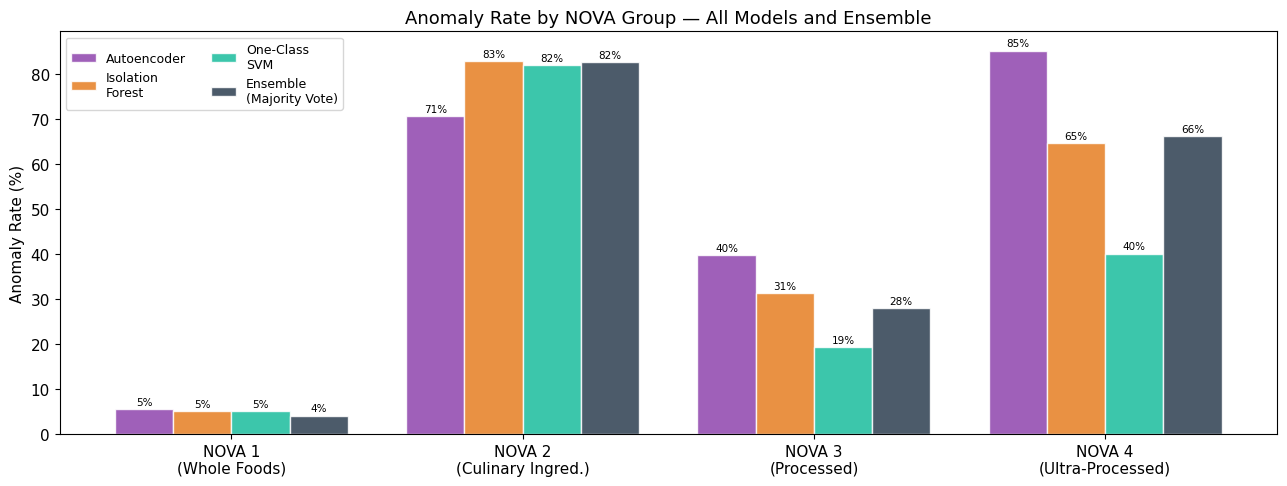

In [19]:
plotter.plot_cross_model_anomaly_rates(
    all_flags       = [ae_anomalies, if_anomalies, svm_anomalies,
                       flags_df["ensemble_anomaly"].values],
    y_test_0indexed = y_test.values,
)

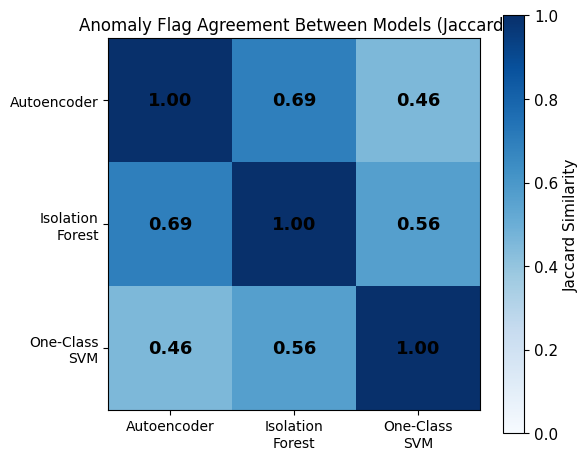

  Autoencoder ∩ Isolation Forest: 21,512 samples flagged by both
  Autoencoder ∩ One-Class SVM: 13,910 samples flagged by both
  Isolation Forest ∩ One-Class SVM: 13,671 samples flagged by both


In [20]:
plotter.plot_jaccard_heatmap(
    binary_flags = [ae_anomalies, if_anomalies, svm_anomalies],
)

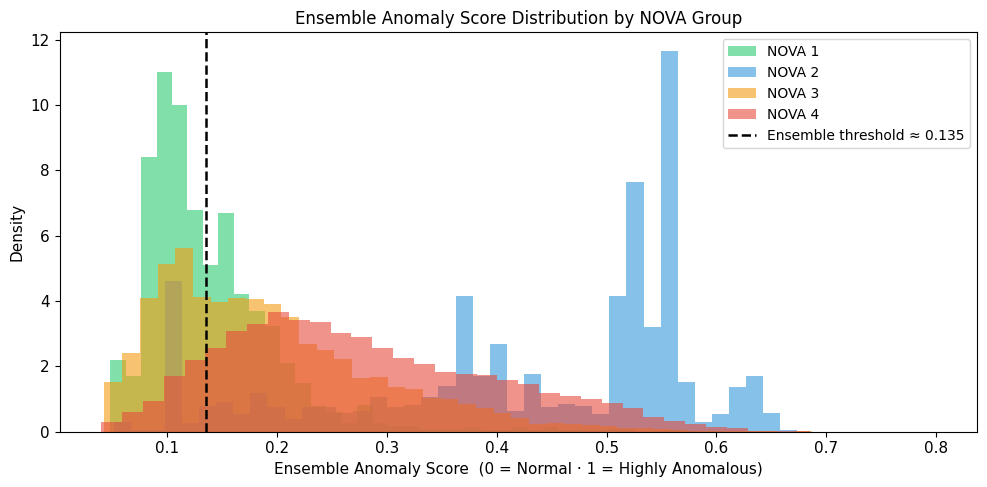

In [21]:
plotter.plot_ensemble_score_distribution(flags_df, y_test.values)

---
## Anomalous Product Analysis

We inspect the top-ranked anomalies from the ensemble to understand *why* they deviate from the whole-food baseline. Comparing mean feature values for (1) NOVA 1 whole foods, (2) the top-20 most anomalous products, and (3) NOVA 4 ultra-processed products reveals which nutritional dimensions drive the anomaly signal.

In [22]:
# ── Annotated test DataFrame ─────────────────────────────────────────────────
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_test_df["nova_group"]       = y_test.values + 1
X_test_df["ensemble_anomaly"] = flags_df["ensemble_anomaly"].values
X_test_df["ensemble_score"]   = flags_df["ensemble_score"].values
X_test_df["ae_score"]         = ae_scores_test
X_test_df["if_score"]         = if_scores_test
X_test_df["svm_score"]        = svm_scores_test
X_test_df["votes"]            = flags_df["votes"].values

# top-20 anomalous products by ensemble score (all 3 models must agree → votes == 3)
top_20 = X_test_df.sort_values("ensemble_score", ascending=False).head(20)

print("Top 20 most anomalous products — NOVA group distribution:")
print(top_20["nova_group"].value_counts().sort_index().rename("count").to_frame().to_string())
print()
print("Top 10 anomalies (ensemble score + model votes):")
display(top_20[["nova_group", "ensemble_score", "votes", "ae_score", "if_score", "svm_score"]].head(10).round(4))

Top 20 most anomalous products — NOVA group distribution:
            count
nova_group       
2               1
3               1
4              18

Top 10 anomalies (ensemble score + model votes):


,nova_group,ensemble_score,votes,ae_score,if_score,svm_score
9504,4,0.7994,3,23.4970,0.0199,72.1406
40411,4,0.7393,3,5.6315,0.2715,72.1403
38449,4,0.7178,3,7.4315,0.2102,72.1377
28577,4,0.7060,3,2.7919,0.2809,72.0366
23006,4,0.6991,3,8.2326,0.1712,72.1393
40075,3,0.6872,3,2.7958,0.2563,72.0322
26905,4,0.6852,3,3.0123,0.2495,72.1155
31931,4,0.6815,3,3.3124,0.2391,72.1262
42067,4,0.6781,3,5.5827,0.1930,72.0629
31780,2,0.6738,3,3.8395,0.2216,71.5145


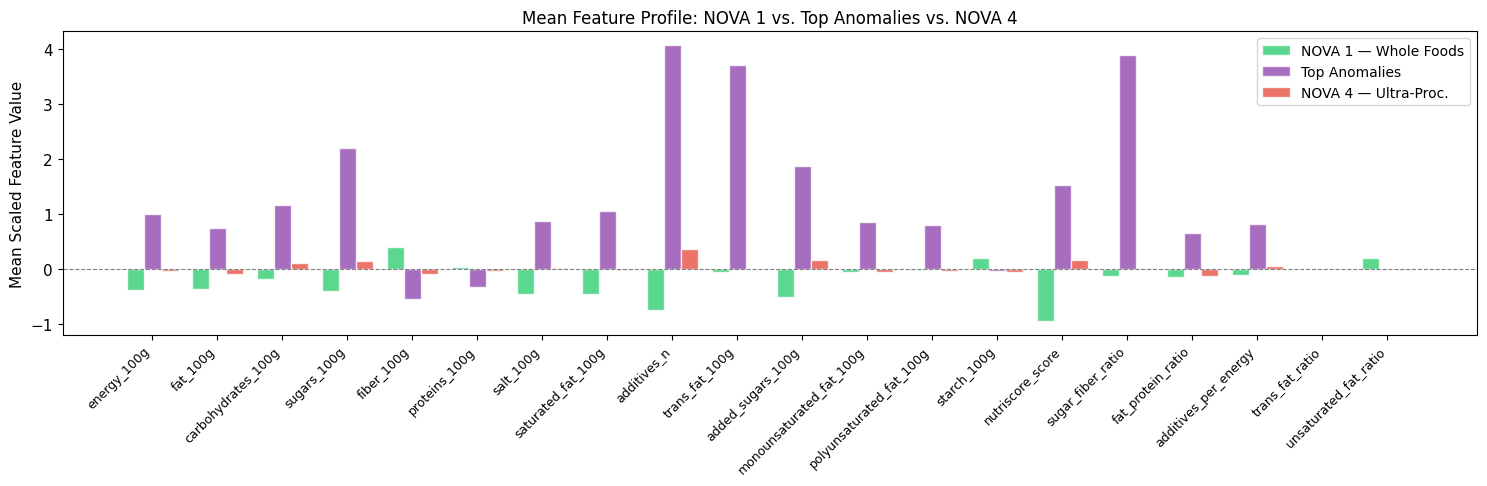


Top 5 features by absolute deviation (Anomaly − NOVA 1):


,Anomaly − NOVA1,NOVA4 − NOVA1
additives_n,4.801,1.107
sugar_fiber_ratio,4.012,0.157
trans_fat_100g,3.747,0.053
sugars_100g,2.598,0.537
nutriscore_score,2.472,1.111


In [23]:
plotter.plot_feature_profile(X_test_df, top_20, feature_names)

---
## Combined Inference: NOVA Classification + Anomaly Detection

This section demonstrates how both use cases operate together in a single inference pipeline. Given raw (unscaled) nutritional feature vectors, the function:
1. Scales the input using the fitted StandardScaler from Notebook 02
2. Predicts the NOVA processing tier and confidence via the XGBoost classifier (Use Case 1)
3. Scores each product with all three anomaly models (Use Case 2)
4. Returns a unified result with the NOVA prediction, per-model anomaly scores, majority-vote anomaly flag, and an ensemble score

In [24]:
# ── Load the trained NOVA classifier (XGBoost from Notebook 04) ───────────────
nova_classifier = XGBClassifier()
nova_classifier.load_model(ARTIFACTS_DIR / "xgb_baseline.json")
print(f"NOVA classifier loaded from {ARTIFACTS_DIR / 'xgb_baseline.json'}")

NOVA classifier loaded from models\xgb_baseline.json


In [25]:
# run combined inference on the full test set using the imported function
combined_df = predict_nova_and_anomaly(
    X_raw            = X_test.values,
    scaler           = scaler,
    nova_classifier  = nova_classifier,
    autoencoder      = autoencoder,
    ae_threshold     = ae_threshold,
    iso_forest       = iso_forest,
    oc_svm           = oc_svm,
)
combined_df["true_nova"] = y_test.values + 1

print("Combined inference results (first 10 rows):")
display(combined_df.head(10))

Combined inference results (first 10 rows):


,nova_pred,nova_confidence,ae_score,if_score,svm_score,ensemble_score,anomaly_votes,is_anomalous,true_nova
0,1,0.8044,0.017952,0.025637,-4.171065,0.2567,2,True,4
1,4,0.7064,0.728986,0.150186,25.682937,0.4462,3,True,4
2,3,0.7697,0.001548,-0.029289,-18.872667,0.1730,0,False,3
3,1,0.9186,0.011208,-0.066211,-23.375082,0.1321,1,False,3
4,3,0.6225,0.090831,0.047291,-20.635633,0.2282,2,True,4
5,1,0.7674,0.004974,-0.087948,-21.194279,0.1214,0,False,1
6,1,0.8162,0.014303,-0.037798,-23.314631,0.1541,1,False,4
7,3,0.5832,0.062484,0.039196,-12.172152,0.2453,2,True,4
8,1,0.8162,0.000663,-0.137708,-32.666418,0.0509,0,False,1
9,1,0.7392,0.018484,-0.018600,-13.820629,0.1956,1,False,4


In [26]:
# ── Summary table: NOVA confidence + anomaly rate by true NOVA group ──────────
summary = (
    combined_df.groupby("true_nova")
    .agg(
        n_samples         = ("is_anomalous", "count"),
        anomaly_rate_pct  = ("is_anomalous", lambda x: round(x.mean() * 100, 1)),
        mean_ens_score    = ("ensemble_score", lambda x: round(x.mean(), 4)),
        mean_nova_conf    = ("nova_confidence", lambda x: round(x.mean(), 4)),
        nova_correct_pct  = ("nova_pred",
                             lambda x: round((x == combined_df.loc[x.index, "true_nova"]).mean() * 100, 1)),
    )
    .rename(index={g: f"NOVA {g}" for g in range(1, 5)})
    .rename(columns={
        "n_samples":        "N Samples",
        "anomaly_rate_pct": "Anomaly Rate (%)",
        "mean_ens_score":   "Mean Ensemble Score",
        "mean_nova_conf":   "Mean NOVA Confidence",
        "nova_correct_pct": "NOVA Accuracy (%)",
    })
)

print("Combined Inference Summary by True NOVA Group")
display(summary)

Combined Inference Summary by True NOVA Group


,N Samples,Anomaly Rate (%),Mean Ensemble Score,Mean NOVA Confidence,NOVA Accuracy (%)
true_nova,,,,,
NOVA 1,5377,4.1,0.1390,0.8133,97.7
NOVA 2,1643,82.5,0.4267,0.7366,0.0
NOVA 3,8992,27.9,0.1911,0.7496,27.3
NOVA 4,28770,66.2,0.2760,0.6849,21.5


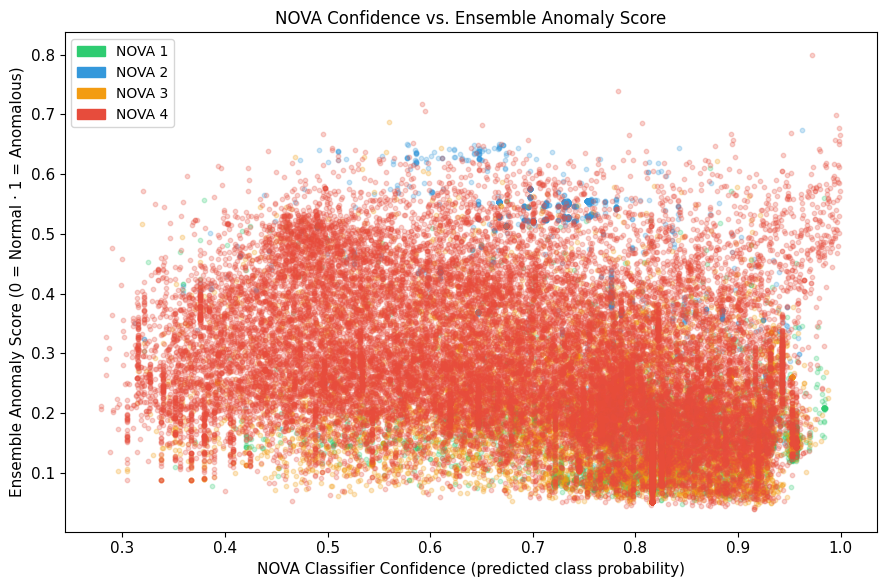

In [27]:
plotter.plot_confidence_vs_anomaly_score(combined_df)

---
## Save Artifacts

Persist all trained anomaly models, the autoencoder threshold, and the test-set anomaly scores so downstream consumers (the backend API, the next notebook, or a production scoring service) can load them without re-training.

In [28]:
# ── Save trained anomaly models and metadata ──────────────────────────────────
anomaly_artifact = {
    "autoencoder":      autoencoder,              # MLPRegressor auto-associative network
    "isolation_forest": iso_forest,               # IsolationForest (contamination=0.05)
    "one_class_svm":    oc_svm,                   # OneClassSVM (rbf, nu=0.05)
    "ae_threshold":     float(ae_threshold),       # 95th percentile of NOVA 1 train errors
    "ae_train_errors":  scorer.ae_train_errors,   # NOVA 1 training reconstruction errors
    "feature_names":    feature_names,             # column order for inference
    "nova1_train_size": int(X_nova1_train.shape[0]),
}
joblib.dump(anomaly_artifact, ARTIFACTS_DIR / "anomaly_models.joblib")

# ── Save test-set anomaly scores as a parquet for downstream analysis ─────────
scores_out = pd.DataFrame({
    "nova_group":       y_test.values + 1,
    "ae_score":         ae_scores_test,
    "if_score":         if_scores_test,
    "svm_score":        svm_scores_test,
    "ae_anomaly":       ae_anomalies,
    "if_anomaly":       if_anomalies,
    "svm_anomaly":      svm_anomalies,
    "ensemble_score":   flags_df["ensemble_score"].values,
    "ensemble_anomaly": flags_df["ensemble_anomaly"].values,
    "anomaly_votes":    flags_df["votes"].values,
})
scores_out.to_parquet(RESULTS_DIR / "anomaly_scores_test.parquet", index=False)

print("Artifacts saved:")
print(f"  {ARTIFACTS_DIR / 'anomaly_models.joblib'}        — 3 trained models + threshold")
print(f"  {RESULTS_DIR   / 'anomaly_scores_test.parquet'}  — test-set anomaly scores")
print()
print("Saved model summary:")
for key, val in anomaly_artifact.items():
    if key not in ("ae_train_errors", "feature_names"):
        print(f"  {key}: {val}")

Artifacts saved:
  models\anomaly_models.joblib        — 3 trained models + threshold
  models\anomaly_scores_test.parquet  — test-set anomaly scores

Saved model summary:
  autoencoder: MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32, 8, 32, 64),
             max_iter=500, n_iter_no_change=20, random_state=42, tol=1e-05)
  isolation_forest: IsolationForest(contamination=0.05, n_estimators=300, n_jobs=-1,
                random_state=42)
  one_class_svm: OneClassSVM(nu=0.05)
  ae_threshold: 0.009474080059588653
  nova1_train_size: 21505


---
## Summary

### Use Case 2: Anomaly Detection Design

Three complementary one-class anomaly detectors were trained exclusively on **NOVA 1 (unprocessed whole foods)** from the combined train+validation set, then scored on the full test set spanning all four NOVA groups.

| Model | Algorithm | Anomaly Score | Threshold |
|-------|-----------|---------------|-----------|
| **Autoencoder** | MLPRegressor bottleneck (64→32→8→32→64) | MSE reconstruction error | 95th percentile of NOVA 1 train errors |
| **Isolation Forest** | 300-tree random partition ensemble | −decision_function | 0 (contamination = 5%) |
| **One-Class SVM** | RBF kernel hyperplane (nu=0.05) | −decision_function | 0 (nu = 5%) |

### Key Findings

- **Anomaly scores rise monotonically from NOVA 1 → NOVA 4** across all three models, validating the whole-food baseline approach — products with more industrial processing deviate increasingly from the learned "normal"
- **NOVA 1 false-positive rate** stays near 5% for all models (matching `contamination` / `nu` settings), confirming the models are not over-flagging clean data
- **Ensemble (majority vote ≥ 2/3)** reduces individual model noise and provides a more stable anomaly signal than any single detector
- **Per-feature reconstruction error** (Autoencoder) pinpoints *which* nutritional dimensions are most surprising — additive-count and sugar/fat ratio features drive the largest errors for NOVA 4 products
- **NOVA 1 products with high anomaly scores** represent true within-tier outliers and may indicate data quality issues in the Open Food Facts crowdsourced dataset

### Integration with the Full Pipeline

| Use Case | Question Answered | Output |
|----------|-------------------|--------|
| **Use Case 1** (Notebooks 01–04) | "What NOVA processing tier is this product?" | NOVA 1–4 + class confidence |
| **Use Case 2** (This Notebook) | "How far does this product deviate from whole-food nutrition?" | Ensemble anomaly score [0–1] + anomaly flag |

The `predict_nova_and_anomaly()` function in this notebook provides a **single entry point** that answers both questions simultaneously, ready to be wrapped by the backend REST API (`backend/main.py`).

### Saved Artifacts
- `models/anomaly_models.joblib` — all 3 trained models + autoencoder threshold + feature metadata
- `models/anomaly_scores_test.parquet` — per-sample anomaly scores and flags for the test set